In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

/kaggle/input/competitions/flight-delays-fall-2018/sample_submission.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_test.csv.zip


**Начало:** Загрузка нужных файлов (Действие выше)

In [2]:
DATA = '/kaggle/input/flight-delays-fall-2018'
train = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip')
test = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018//flight_delays_test.csv.zip')
print('train:', train.shape, '| test:', test.shape)
train.head()

train: (100000, 9) | test: (100000, 8)


,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


**Загрузка данных** (Действие выше)

In [3]:
print("Обучающая выборка:", train.shape)
print(train['dep_delayed_15min'].value_counts())
print("\nБолее подробная информация о столбцах:")
train.info()


Обучающая выборка: (100000, 9)
dep_delayed_15min
N    80956
Y    19044
Name: count, dtype: int64

Более подробная информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Month              100000 non-null  object
 1   DayofMonth         100000 non-null  object
 2   DayOfWeek          100000 non-null  object
 3   DepTime            100000 non-null  int64 
 4   UniqueCarrier      100000 non-null  object
 5   Origin             100000 non-null  object
 6   Dest               100000 non-null  object
 7   Distance           100000 non-null  int64 
 8   dep_delayed_15min  100000 non-null  object
dtypes: int64(2), object(7)
memory usage: 6.9+ MB


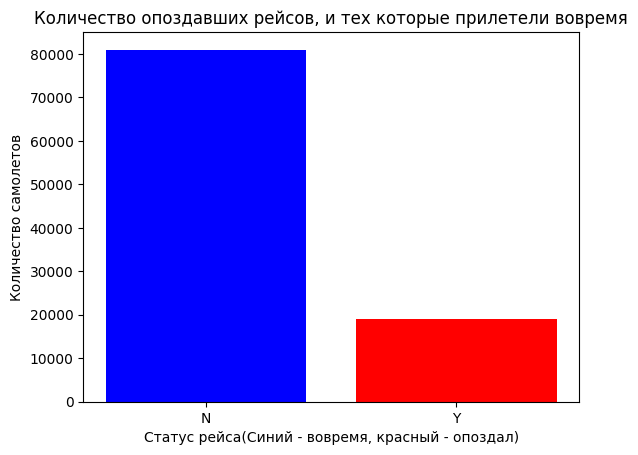

In [4]:
n = train['dep_delayed_15min'].value_counts()
plt.bar(n.index, n.values, color = ['blue','red'])
plt.title('Количество опоздавших рейсов, и тех которые прилетели вовремя')
plt.xlabel('Статус рейса(Синий - вовремя, красный - опоздал)')
plt.ylabel('Количество самолетов')
plt.show()

**Разведочный анализ** (Действия выше)

In [5]:
def transform(df):
    df = df.copy()
    # Поля 'c-8', 'c-21', 'c-7' -> целые числа
    for col in ['Month', 'DayofMonth', 'DayOfWeek']:
        df[col] = df[col].str.replace('c-', '').astype(int)
    # Час вылета из DepTime (hhmm)
    df['Hour'] = (df['DepTime'] // 100).astype(int)
    df['Minute'] = (df['DepTime'] % 100).astype(int)
    return df
train_fe = transform(train)
test_fe = transform(test)
# Целевая переменная 'Y'/'N' -> 1/0
train_fe['dep_delayed_15min'] = train_fe['dep_delayed_15min'].map({'Y': 1, 'N': 0})
# Сохранение обработанного датасета (load -> transform -> save)
os.makedirs('/kaggle/working', exist_ok=True)
train_fe.to_parquet('/kaggle/working/train_processed.parquet', index=False)
print('Сохранено:', train_fe.shape)
train_fe.head()

Сохранено: (100000, 11)


,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min,Hour,Minute
0,8,21,7,1934,AA,ATL,DFW,732,0,19,34
1,4,20,3,1548,US,PIT,MCO,834,0,15,48
2,9,2,5,1422,XE,RDU,CLE,416,0,14,22
3,11,25,6,1015,OO,DEN,MEM,872,0,10,15
4,10,7,6,1828,WN,MDW,OMA,423,1,18,28
